# **Insights about the three different batches for which the score data has been provided**

Importing Libraries

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading the Dataset

In [2]:
df = pd.read_csv("scores_data.csv")
df.head()

,Batch,User_ID,Score
0,AI_ELITE_7,uid_149,6 / 7
1,AI_ELITE_7,uid_148,6 / 7
2,AI_ELITE_7,uid_147,7 / 7
3,AI_ELITE_7,uid_146,7 / 7
4,AI_ELITE_7,uid_145,4 / 7


Converting "Score" column from String to Integer

In [6]:
df.columns = df.columns.str.strip()
df["Score"] = df["Score"].str.split("/").str[0].astype(int)
df.head()

,Batch,User_ID,Score,Scor
0,AI_ELITE_7,uid_149,6,6
1,AI_ELITE_7,uid_148,6,6
2,AI_ELITE_7,uid_147,7,7
3,AI_ELITE_7,uid_146,7,7
4,AI_ELITE_7,uid_145,4,4


Information and Validating

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Batch    149 non-null    object
 1   User_ID  149 non-null    object
 2   Score    149 non-null    int64 
 3   Scor     149 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 4.8+ KB
None


In [8]:
print("Unique Batches: ",df["Batch"].unique())

Unique Batches:  ['AI_ELITE_7' 'AI_ELITE_6' 'AI_ELITE_4']


In [9]:
print("Score range: ",df["Score"].min(), "to", df["Score"].max())

Score range:  0 to 7


Batch-wise Descriptive Statistics

In [10]:
batch_stats = (
    df.groupby("Batch")["Score"]
    .agg(
        Students="count",
        Average="mean",
        Median="median",
        Min="min",
        Max="max",
        Std_dev="std"
    )
    .round(2)
    .reset_index()
)
batch_stats

,Batch,Students,Average,Median,Min,Max,Std_dev
0,AI_ELITE_4,48,3.79,4.0,0,7,1.44
1,AI_ELITE_6,48,4.23,4.0,0,7,1.64
2,AI_ELITE_7,53,5.06,5.0,2,7,1.45


Score Distribution

In [13]:
def categorize(score):
  if score<=2:
    return "Low(0-2)"
  elif score>2 and score<=5:
    return "Mediun(3-5)"
  else:
    return "High(6-7)"

df["Score_Category"]= df["Score"].apply(categorize)

distribution =(
    df.groupby(["Batch","Score_Category"])
    .size()
    .unstack(fill_value=0)
)
distribution

Score_Category,High(6-7),Low(0-2),Mediun(3-5)
Batch,,,
AI_ELITE_4,4,9,35
AI_ELITE_6,9,6,33
AI_ELITE_7,23,2,28


VISUALIZATIONS

Bar-Chart (Avg Score per Batch)

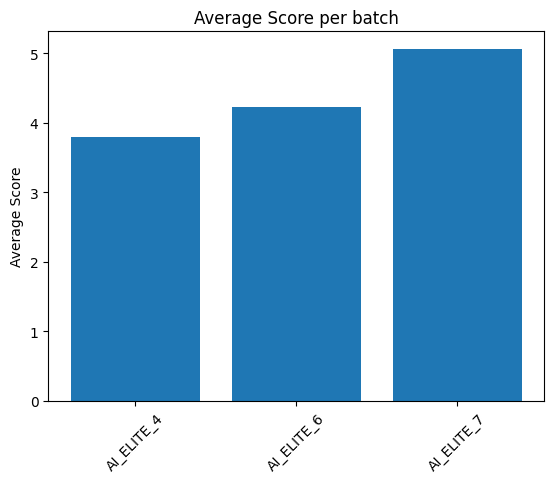

In [15]:
plt.figure()
plt.bar(batch_stats["Batch"],batch_stats["Average"])
plt.ylabel("Average Score")
plt.title("Average Score per batch")
plt.xticks(rotation=45)
plt.show()

Box-Plot (Score-spread comparison)

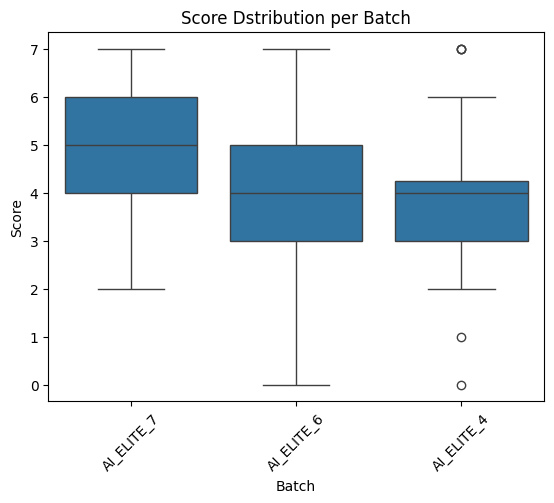

In [17]:
plt.figure()
sns.boxplot(x="Batch", y="Score",data=df)
plt.title("Score Dstribution per Batch")
plt.xticks(rotation=45)
plt.show()

Final Prediction

In [19]:
best_batch = batch_stats.loc[batch_stats["Average"].idxmax(), "Batch"]
consistent_batch = batch_stats.loc[batch_stats["Std_dev"].idxmin(), "Batch"]

In [21]:
print(f"Best performing batch (highest average score): {best_batch}")
print(f"Most consistent batch (lowest variation): {consistent_batch}")

Best performing batch (highest average score): AI_ELITE_7
Most consistent batch (lowest variation): AI_ELITE_4
